# Compares LSTM vs GRU performance

In [1]:
import sys
sys.path.append("..")

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from src.data.fetch_data import load_all_raw, STOCK_UNIVERSE
from src.data.preprocess import preprocess_all
from src.utils.metrics import evaluate
from src.models.lstm import (
    LSTMModel, GRUModel, train_model,
    predict_test_rnn, forecast_future_rnn,
    run_lstm_pipeline, run_gru_pipeline
)

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (14, 5)
print(f"PyTorch {torch.__version__} | Device: {'cuda' if torch.cuda.is_available() else 'cpu'}")

PyTorch 2.11.0+cu130 | Device: cpu


In [2]:
raw = load_all_raw()
processed = preprocess_all(raw, save=False)
print(f"Loaded {len(processed)} stocks")

INFO | Preprocessing HDFCBANK.NS …
INFO | Preprocessing ICICIBANK.NS …
INFO | Preprocessing TCS.NS …
INFO | Preprocessing INFY.NS …
INFO | Preprocessing SUNPHARMA.NS …
INFO | Preprocessing DRREDDY.NS …
INFO | Preprocessing HINDUNILVR.NS …
INFO | Preprocessing ITC.NS …
INFO | Preprocessing MARUTI.NS …
INFO | Preprocessing complete.


Loaded 9 stocks


In [3]:
TICKER = "TCS.NS"
SEQ_LEN = 60
EPOCHS = 30

d = processed[TICKER]
train, test = d["train"], d["test"]
tr_sc, te_sc, scaler = d["train_scaled"], d["test_scaled"], d["scaler"]

print(f"Train scaled shape: {tr_sc.shape}")
print(f"Test scaled shape:  {te_sc.shape}")

Train scaled shape: (1110, 1)
Test scaled shape:  (125, 1)


INFO |     Epoch 10/30  loss=0.002889
INFO |     Epoch 20/30  loss=0.002013
INFO |     Epoch 30/30  loss=0.001747


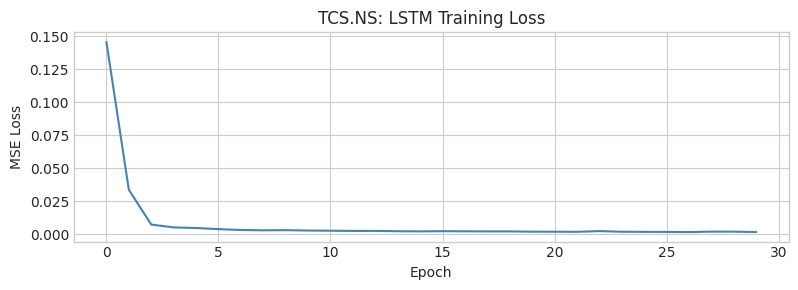

In [4]:
lstm_model = LSTMModel(hidden_size=64)
losses = train_model(lstm_model, tr_sc, seq_len=SEQ_LEN, epochs=EPOCHS)

fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(losses, color="steelblue")
ax.set_xlabel("Epoch")
ax.set_ylabel("MSE Loss")
ax.set_title(f"{TICKER}: LSTM Training Loss")
plt.tight_layout()
plt.show()


LSTM Metrics for TCS.NS:
  Ticker: TCS.NS
  Model: LSTM
  RMSE: 52.2917
  MAPE: 1.3225
  DirAcc: 51.61


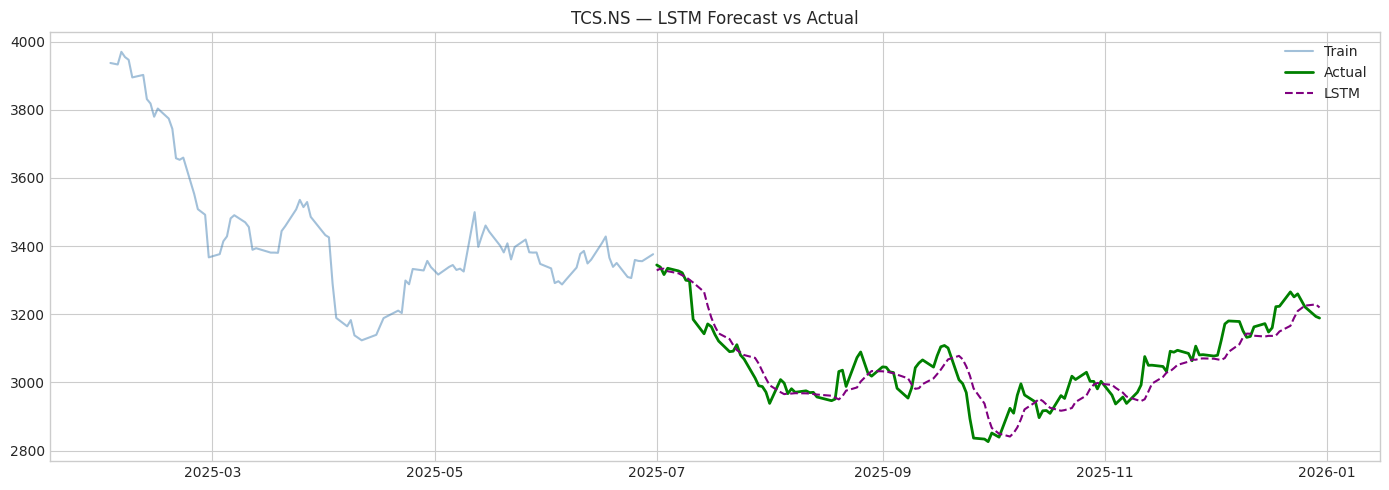

In [5]:
raw_preds = predict_test_rnn(lstm_model, tr_sc, te_sc, scaler, SEQ_LEN)
pred = pd.Series(raw_preds, index=test.index, name="LSTM_Pred")

metrics = evaluate(test.values, pred.values, "LSTM", TICKER)
print(f"\nLSTM Metrics for {TICKER}:")
for k, v in metrics.items():
    print(f"  {k}: {v}")

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(train[-100:], label="Train", color="steelblue", alpha=0.5)
ax.plot(test, label="Actual", color="green", linewidth=2)
ax.plot(pred, label="LSTM", color="purple", linewidth=1.5, linestyle="--")
ax.set_title(f"{TICKER} — LSTM Forecast vs Actual")
ax.legend()
plt.tight_layout()
plt.show()

### Future Forecast


LSTM Forecast — TCS.NS:
  2025-12-31: ₹3205.10
  2026-01-01: ₹3193.31
  2026-01-02: ₹3183.62
  2026-01-05: ₹3175.29
  2026-01-06: ₹3167.76


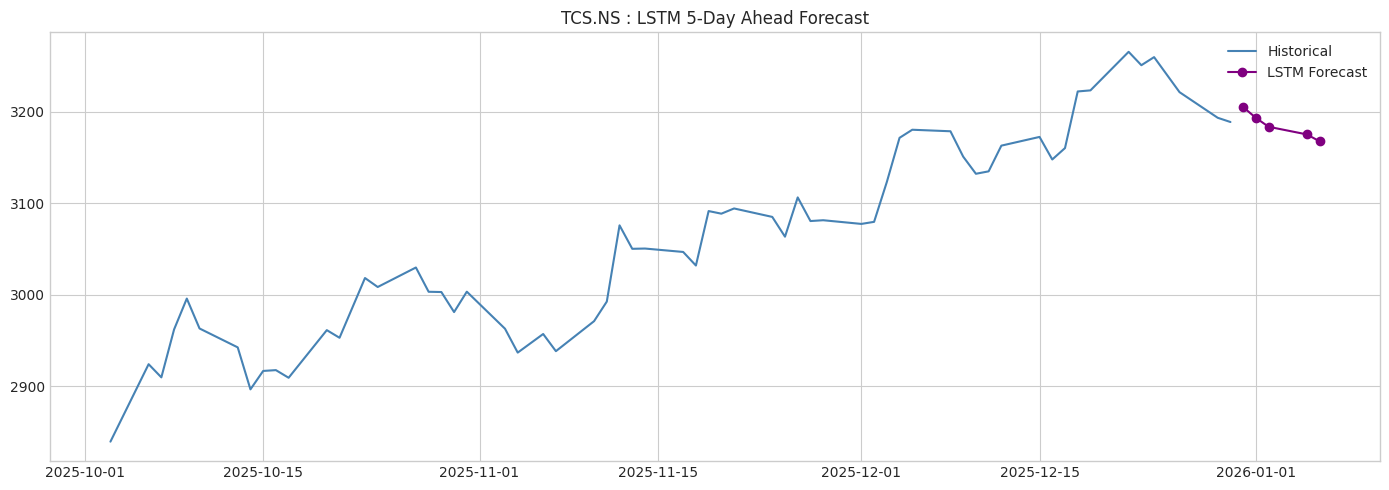

In [6]:
fc = forecast_future_rnn(lstm_model, tr_sc, te_sc, scaler, SEQ_LEN, n_periods=5)
full = pd.concat([train, test])
future_dates = pd.bdate_range(start=full.index[-1] + pd.Timedelta(days=1), periods=5)

print(f"\nLSTM Forecast — {TICKER}:")
for d_val, v in zip(future_dates, fc):
    print(f"  {d_val.date()}: ₹{v:.2f}")

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(full[-60:], label="Historical", color="steelblue")
ax.plot(future_dates, fc, label="LSTM Forecast", color="purple", marker="o")
ax.set_title(f"{TICKER} : LSTM 5-Day Ahead Forecast")
ax.legend()
plt.tight_layout()
plt.show()

In [7]:
lstm_preds, lstm_fc, lstm_met = run_lstm_pipeline(processed, n_forecast=5, epochs=EPOCHS)

lstm_df = pd.DataFrame(lstm_met)
print("\n── LSTM Results ──")
print(lstm_df.to_string())
print(f"\nAvg MAPE: {lstm_df['MAPE'].mean():.2f}%  |  Avg DirAcc: {lstm_df['DirAcc'].mean():.1f}%")

INFO | LSTM | HDFCBANK.NS
INFO |     Epoch 10/30  loss=0.002827
INFO |     Epoch 20/30  loss=0.002082
INFO |     Epoch 30/30  loss=0.001679
INFO | LSTM | ICICIBANK.NS
INFO |     Epoch 10/30  loss=0.001146
INFO |     Epoch 20/30  loss=0.001102
INFO |     Epoch 30/30  loss=0.000921
INFO | LSTM | TCS.NS
INFO |     Epoch 10/30  loss=0.002792
INFO |     Epoch 20/30  loss=0.002067
INFO |     Epoch 30/30  loss=0.001571
INFO | LSTM | INFY.NS
INFO |     Epoch 10/30  loss=0.003030
INFO |     Epoch 20/30  loss=0.002329
INFO |     Epoch 30/30  loss=0.001747
INFO | LSTM | SUNPHARMA.NS
INFO |     Epoch 10/30  loss=0.000968
INFO |     Epoch 20/30  loss=0.000782
INFO |     Epoch 30/30  loss=0.000603
INFO | LSTM | DRREDDY.NS
INFO |     Epoch 10/30  loss=0.002167
INFO |     Epoch 20/30  loss=0.001634
INFO |     Epoch 30/30  loss=0.001199
INFO | LSTM | HINDUNILVR.NS
INFO |     Epoch 10/30  loss=0.002086
INFO |     Epoch 20/30  loss=0.001708
INFO |     Epoch 30/30  loss=0.001282
INFO | LSTM | ITC.NS
INFO 


── LSTM Results ──
          Ticker Model       RMSE    MAPE  DirAcc
0    HDFCBANK.NS  LSTM    23.2690  2.1926   42.74
1   ICICIBANK.NS  LSTM    21.5365  1.2279   46.77
2         TCS.NS  LSTM    61.6184  1.6457   52.42
3        INFY.NS  LSTM    33.2960  1.8571   50.00
4   SUNPHARMA.NS  LSTM    32.0839  1.4255   47.58
5     DRREDDY.NS  LSTM    23.6581  1.5133   45.16
6  HINDUNILVR.NS  LSTM    37.2986  1.0375   49.19
7         ITC.NS  LSTM    11.1139  2.5091   48.39
8      MARUTI.NS  LSTM  1279.0856  6.9543   46.77

Avg MAPE: 2.26%  |  Avg DirAcc: 47.7%


In [8]:
gru_preds, gru_fc, gru_met = run_gru_pipeline(processed, n_forecast=5, epochs=EPOCHS)

gru_df = pd.DataFrame(gru_met)
print("\n── GRU Results ──")
print(gru_df.to_string())
print(f"\nAvg MAPE: {gru_df['MAPE'].mean():.2f}%  |  Avg DirAcc: {gru_df['DirAcc'].mean():.1f}%")

INFO | GRU | HDFCBANK.NS
INFO |     Epoch 10/30  loss=0.001929
INFO |     Epoch 20/30  loss=0.001681
INFO |     Epoch 30/30  loss=0.001144
INFO | GRU | ICICIBANK.NS
INFO |     Epoch 10/30  loss=0.000720
INFO |     Epoch 20/30  loss=0.000568
INFO |     Epoch 30/30  loss=0.000597
INFO | GRU | TCS.NS
INFO |     Epoch 10/30  loss=0.001931
INFO |     Epoch 20/30  loss=0.001258
INFO |     Epoch 30/30  loss=0.001228
INFO | GRU | INFY.NS
INFO |     Epoch 10/30  loss=0.001674
INFO |     Epoch 20/30  loss=0.001478
INFO |     Epoch 30/30  loss=0.001213
INFO | GRU | SUNPHARMA.NS
INFO |     Epoch 10/30  loss=0.000601
INFO |     Epoch 20/30  loss=0.000434
INFO |     Epoch 30/30  loss=0.000407
INFO | GRU | DRREDDY.NS
INFO |     Epoch 10/30  loss=0.001495
INFO |     Epoch 20/30  loss=0.001091
INFO |     Epoch 30/30  loss=0.000968
INFO | GRU | HINDUNILVR.NS
INFO |     Epoch 10/30  loss=0.001774
INFO |     Epoch 20/30  loss=0.001209
INFO |     Epoch 30/30  loss=0.000986
INFO | GRU | ITC.NS
INFO |     Ep


── GRU Results ──
          Ticker Model      RMSE    MAPE  DirAcc
0    HDFCBANK.NS   GRU    8.0111  0.6431   50.00
1   ICICIBANK.NS   GRU   24.1789  1.4946   53.23
2         TCS.NS   GRU   40.5698  1.0496   53.23
3        INFY.NS   GRU   23.1211  1.2124   51.61
4   SUNPHARMA.NS   GRU   24.7395  1.1016   48.39
5     DRREDDY.NS   GRU   23.1175  1.4193   49.19
6  HINDUNILVR.NS   GRU   33.2298  1.0056   47.58
7         ITC.NS   GRU    5.3816  1.1110   46.77
8      MARUTI.NS   GRU  970.0274  5.4521   43.55

Avg MAPE: 1.61%  |  Avg DirAcc: 49.3%



── LSTM vs GRU (Avg Across Stocks) ──
           RMSE    MAPE   DirAcc
Model                           
GRU    128.0419  1.6099  49.2833
LSTM   169.2178  2.2626  47.6689


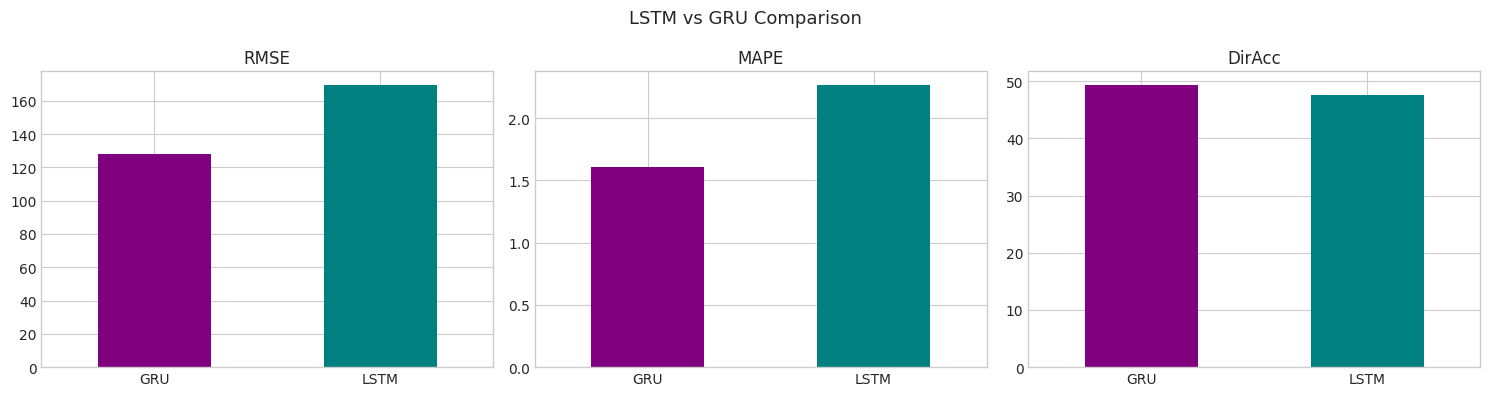

In [9]:
combined = pd.concat([lstm_df, gru_df])
comparison = combined.groupby("Model")[["RMSE", "MAPE", "DirAcc"]].mean().round(4)
print("\n── LSTM vs GRU (Avg Across Stocks) ──")
print(comparison.to_string())

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, metric in enumerate(["RMSE", "MAPE", "DirAcc"]):
    comparison[metric].plot(kind="bar", ax=axes[i], color=["purple", "teal"])
    axes[i].set_title(metric)
    axes[i].set_xlabel("")
    axes[i].tick_params(axis="x", rotation=0)
plt.suptitle("LSTM vs GRU Comparison", fontsize=13)
plt.tight_layout()
plt.show()

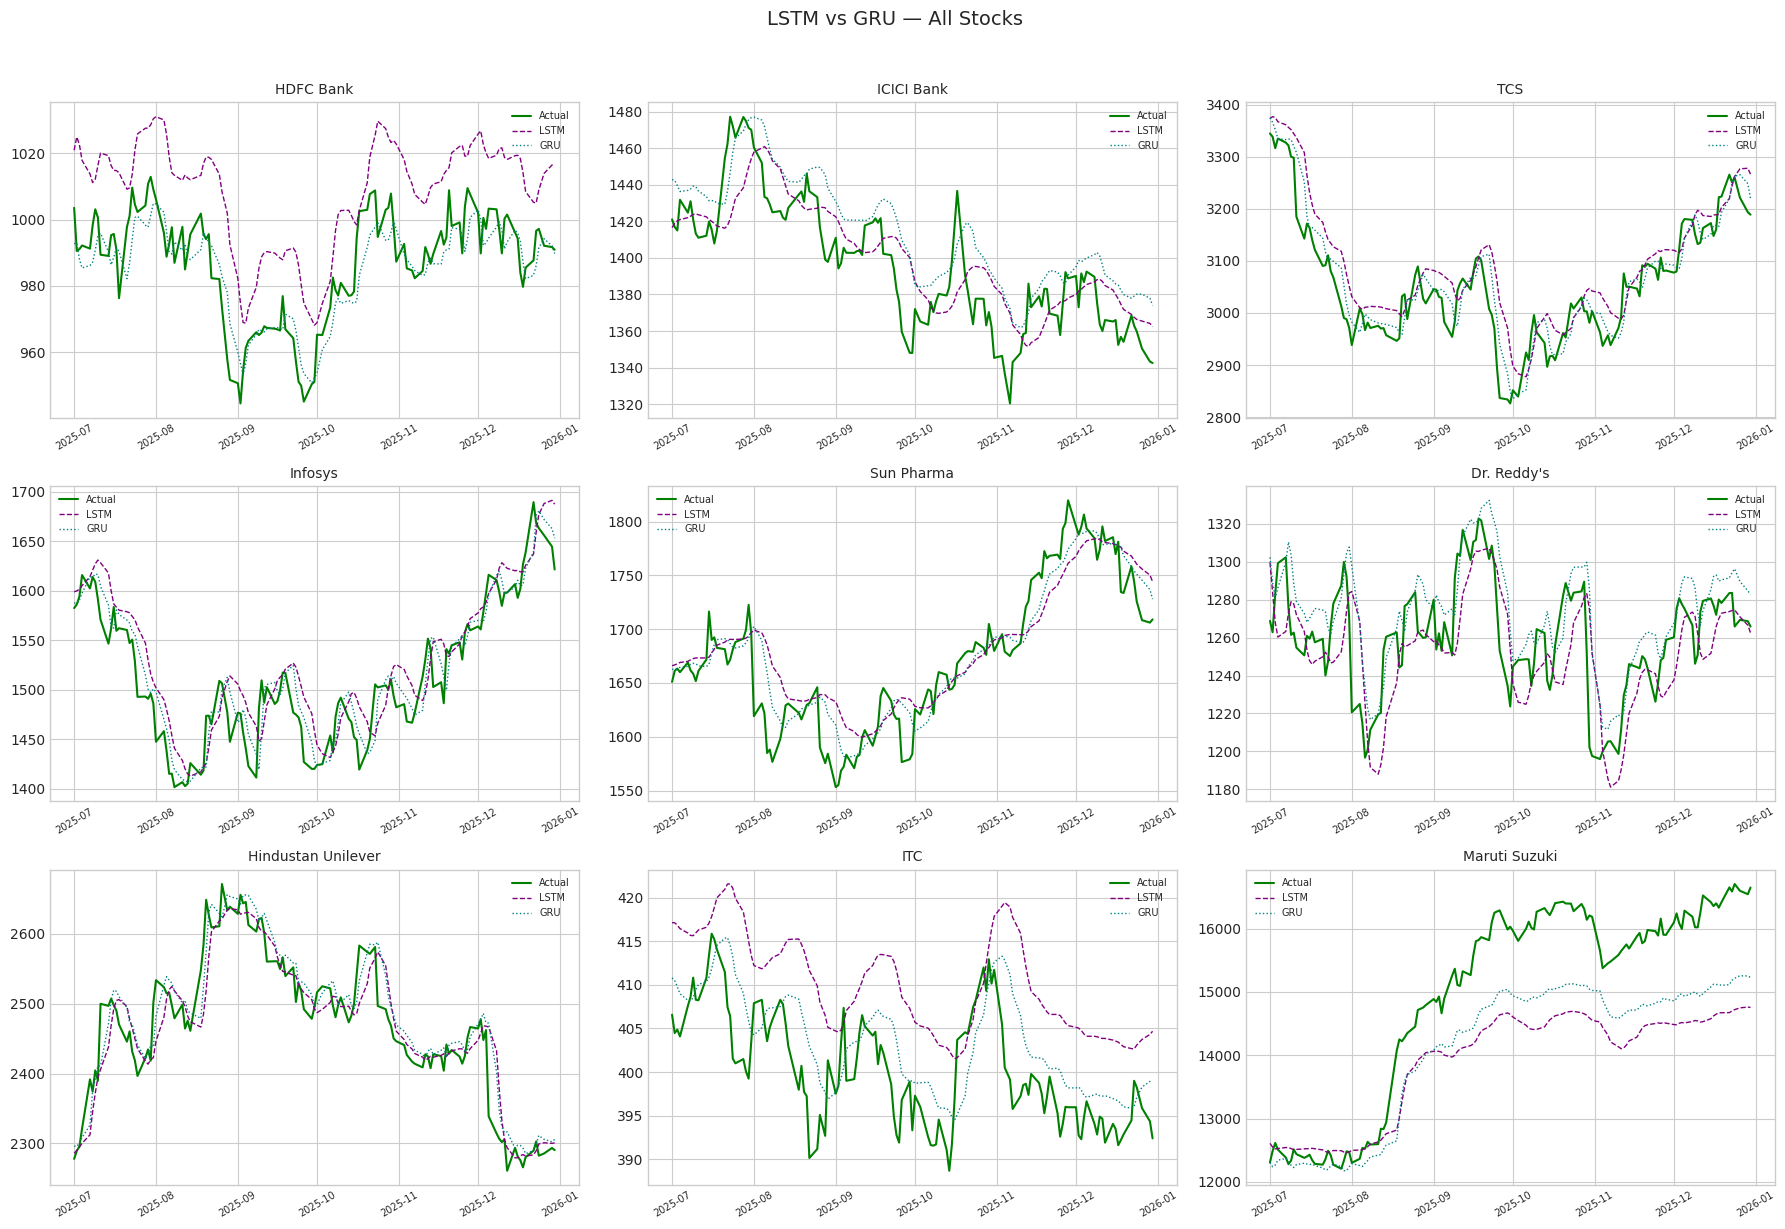

In [10]:
fig, axes = plt.subplots(3, 3, figsize=(18, 12))
axes = axes.flatten()
for i, ticker in enumerate(list(lstm_preds.keys())[:9]):
    ax = axes[i]
    actual = processed[ticker]["test"]
    ax.plot(actual, label="Actual", color="green", linewidth=1.5)
    ax.plot(lstm_preds[ticker], label="LSTM", color="purple", linewidth=1, linestyle="--")
    if ticker in gru_preds:
        ax.plot(gru_preds[ticker], label="GRU", color="teal", linewidth=1, linestyle=":")
    ax.set_title(STOCK_UNIVERSE.get(ticker, ticker), fontsize=10)
    ax.tick_params(axis="x", rotation=30, labelsize=7)
    ax.legend(fontsize=7)
plt.suptitle("LSTM vs GRU — All Stocks", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()